# build linear regretion 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load preprocessed data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train_reg.csv').squeeze()
y_test  = pd.read_csv('../data/y_test_reg.csv').squeeze()

print("✅ Data loaded!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features used:    {X_train.shape[1]}")

✅ Data loaded!
Training samples: 316
Testing samples:  79
Features used:    16


In [2]:
# Build the model — just 2 lines! 🔥
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

print("✅ Linear Regression model trained!")
print(f"Intercept: {model_lr.intercept_:.4f}")
print("\nFeature coefficients:")
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_lr.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

✅ Linear Regression model trained!
Intercept: 8.9561

Feature coefficients:
   Feature  Coefficient
        G2     3.092760
 pass_fail     2.115588
        G1     0.375670
     goout     0.220240
      Medu     0.195855
traveltime     0.074510
      Mjob     0.055535
       sex    -0.005190
    higher    -0.006239
   address    -0.010775
      paid    -0.026919
    reason    -0.058406
       age    -0.059635
  romantic    -0.209877
      Fedu    -0.234663
  failures    -0.238055


# evaluate the matrix 


In [3]:
# Make predictions
y_pred = model_lr.predict(X_test)

# Calculate all metrics — this is your Unit 2 syllabus!
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("   LINEAR REGRESSION RESULTS")
print("=" * 40)
print(f"MAE  (Mean Abs Error):    {mae:.4f}")
print(f"MSE  (Mean Sq Error):     {mse:.4f}")
print(f"RMSE (Root Mean Sq Err):  {rmse:.4f}")
print(f"R²   (R-Squared):         {r2:.4f}")
print("=" * 40)

if r2 > 0.7:
    print("✅ Great model! R² above 0.7")
elif r2 > 0.5:
    print("⚠️ Decent model — can improve")
else:
    print("❌ Weak model — needs improvement") 

   LINEAR REGRESSION RESULTS
MAE  (Mean Abs Error):    1.2901
MSE  (Mean Sq Error):     4.1541
RMSE (Root Mean Sq Err):  2.0382
R²   (R-Squared):         0.7974
✅ Great model! R² above 0.7


# visualise predection 

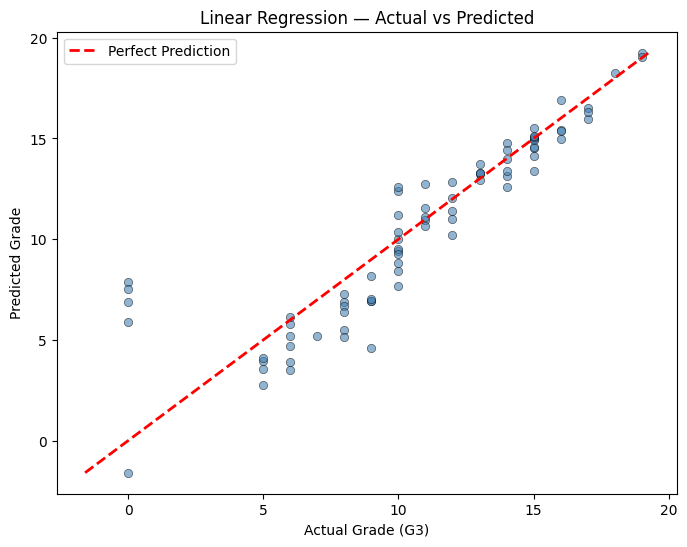

✅ Chart saved!


In [4]:
# Chart 1 — Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6,
            color='steelblue', edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Grade (G3)')
plt.ylabel('Predicted Grade')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.savefig('../notebooks/chart9_lr_actual_vs_pred.png')
plt.show()
print("✅ Chart saved!")

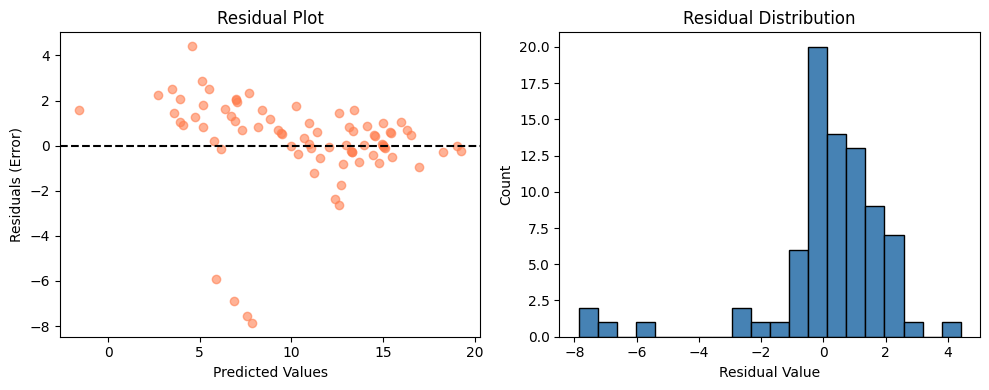

✅ Residual charts saved!


In [5]:
# Chart 2 — Residuals (errors)
residuals = y_test - y_pred

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6, color='coral')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Residual Value')
plt.ylabel('Count')
plt.title('Residual Distribution')

plt.tight_layout()
plt.savefig('../notebooks/chart10_residuals.png')
plt.show()
print("✅ Residual charts saved!")

# polynomial regration

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Build Polynomial Regression (degree 2)
model_poly = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear_regression', LinearRegression())
])

model_poly.fit(X_train, y_train)
y_pred_poly = model_poly.predict(X_test)

# Evaluate
mae_poly  = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly   = r2_score(y_test, y_pred_poly)

print("=" * 40)
print("  POLYNOMIAL REGRESSION RESULTS")
print("=" * 40)
print(f"MAE:   {mae_poly:.4f}")
print(f"RMSE:  {rmse_poly:.4f}")
print(f"R²:    {r2_poly:.4f}")
print("=" * 40)

  POLYNOMIAL REGRESSION RESULTS
MAE:   2.2283
RMSE:  3.2684
R²:    0.4790


# compare both the models

In [7]:
# Side by side comparison
print("\n" + "=" * 50)
print("         MODEL COMPARISON")
print("=" * 50)
print(f"{'Metric':<10} {'Linear Reg':>15} {'Poly Reg':>15}")
print("-" * 50)
print(f"{'MAE':<10} {mae:>15.4f} {mae_poly:>15.4f}")
print(f"{'RMSE':<10} {rmse:>15.4f} {rmse_poly:>15.4f}")
print(f"{'R²':<10} {r2:>15.4f} {r2_poly:>15.4f}")
print("=" * 50)

winner = "Polynomial" if r2_poly > r2 else "Linear"
print(f"\n🏆 Winner: {winner} Regression!")


         MODEL COMPARISON
Metric          Linear Reg        Poly Reg
--------------------------------------------------
MAE                 1.2901          2.2283
RMSE                2.0382          3.2684
R²                  0.7974          0.4790

🏆 Winner: Linear Regression!


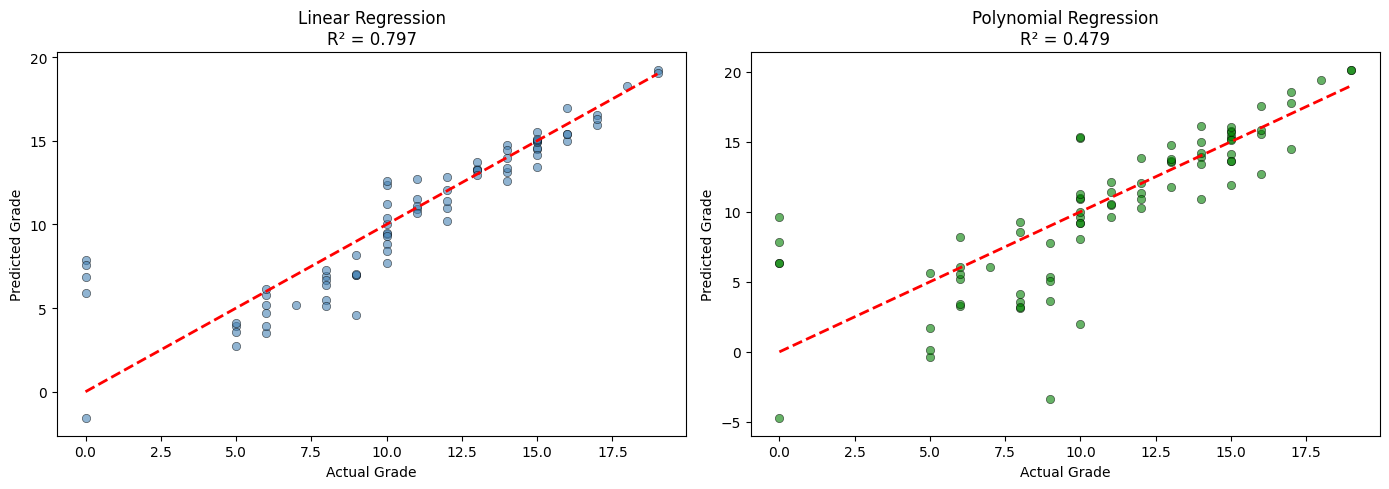

✅ Comparison chart saved!


In [8]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear
axes[0].scatter(y_test, y_pred, alpha=0.6,
                color='steelblue', edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_title(f'Linear Regression\nR² = {r2:.3f}')
axes[0].set_xlabel('Actual Grade')
axes[0].set_ylabel('Predicted Grade')

# Polynomial
axes[1].scatter(y_test, y_pred_poly, alpha=0.6,
                color='green', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_title(f'Polynomial Regression\nR² = {r2_poly:.3f}')
axes[1].set_xlabel('Actual Grade')
axes[1].set_ylabel('Predicted Grade')

plt.tight_layout()
plt.savefig('../notebooks/chart12_model_comparison.png')
plt.show()
print("✅ Comparison chart saved!")

In [9]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Save both models
with open('../models/linear_regression.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

with open('../models/polynomial_regression.pkl', 'wb') as f:
    pickle.dump(model_poly, f)

print("✅ Both models saved!")

# Summary
print("\n" + "="*40)
print("   DAY 4 SUMMARY")
print("="*40)
print(f"Linear Regression R²:     {r2:.4f}")
print(f"Polynomial Regression R²: {r2_poly:.4f}")
print(f"Best model:               {winner} Regression")
print(f"Models saved to:          ../models/")
print("="*40)

✅ Both models saved!

   DAY 4 SUMMARY
Linear Regression R²:     0.7974
Polynomial Regression R²: 0.4790
Best model:               Linear Regression
Models saved to:          ../models/


## Day 4 Summary — Regression Models

### Linear Regression
- MAE: 1.2901           (off by X grade points on average)
- RMSE: 2.0382          
- R²:   0.7974            (model explains X% of grade variation)

### Polynomial Regression (degree=2)
- MAE: 2.2283
- RMSE: 3.2684
- R²:   0.4790


### Winner: Linear  Regression
### Key finding: G2 and G1 are the strongest predictors of G3